First 5 Records:
   Temperature  Rainfall  Humidity  Soil_Moisture  Wind_Speed Drought_Severity
0         29.5      37.0      38.3           55.5        16.4       No Drought
1         41.0     108.4      37.3           64.8        21.1       No Drought
2         36.6     174.6      83.4           23.8        20.2       No Drought
3         34.0     146.4      37.5           51.9         8.1       No Drought
4         25.1     161.3      39.0           47.9         8.0       No Drought

Dataset Shape:
(1000, 6)

Missing Values:
Temperature         0
Rainfall            0
Humidity            0
Soil_Moisture       0
Wind_Speed          0
Drought_Severity    0
dtype: int64

Statistical Summary:
       Temperature    Rainfall     Humidity  Soil_Moisture   Wind_Speed
count  1000.000000  1000.00000  1000.000000    1000.000000  1000.000000
mean     31.803000   101.40150    55.168300      41.775800    14.880500
std       5.842457    58.43944    20.348123      21.488467     5.736151
min      22

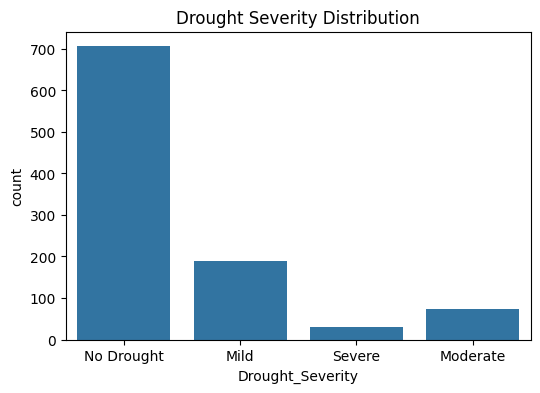

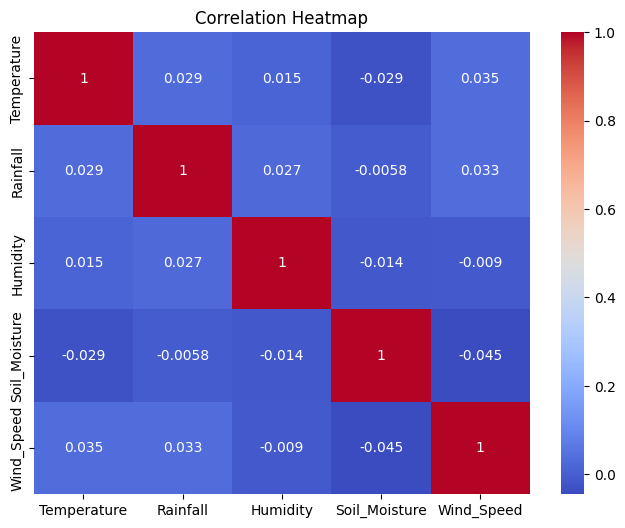

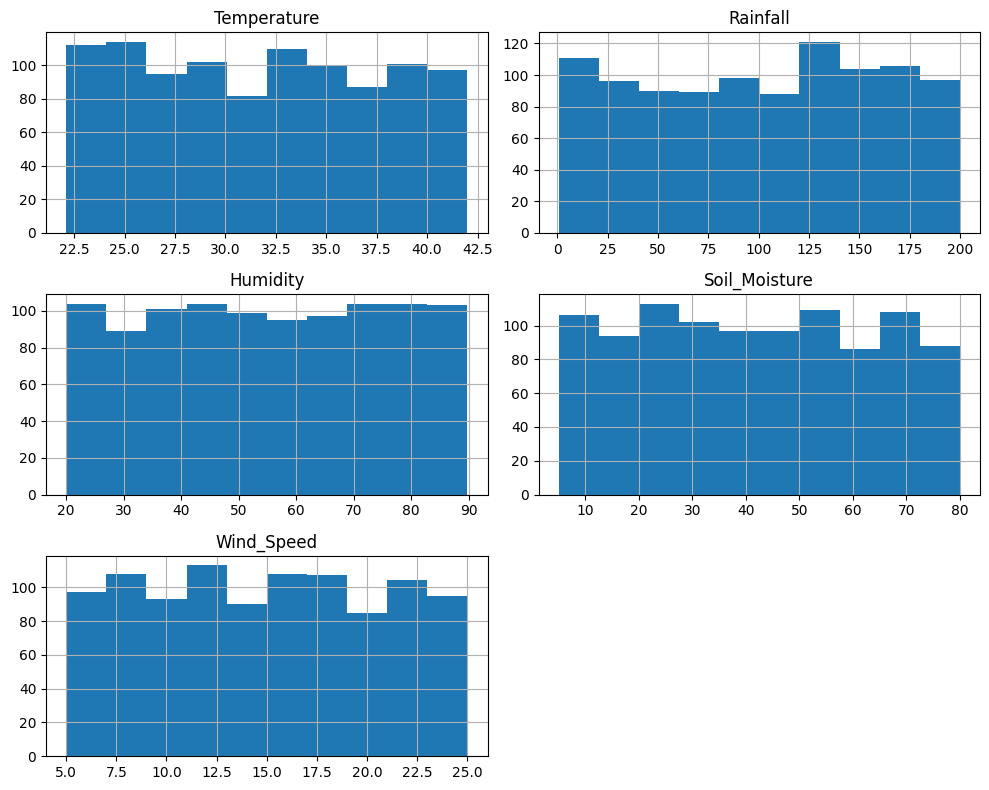

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Accuracy Score:
0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70        38
           1       0.73      0.47      0.57        17
           2       0.94      0.95      0.94       141
           3       0.50      0.50      0.50         4

    accuracy                           0.86       200
   macro avg       0.71      0.66      0.68       200
weighted avg       0.86      0.86      0.86       200



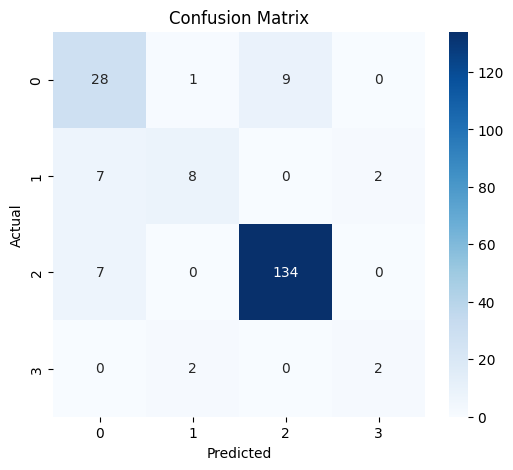


Predicted Drought Severity:
['Moderate']


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
df = pd.read_csv("drought_dataset.csv")

# Display Dataset Information
print("First 5 Records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ---------------- EDA ----------------

# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Drought_Severity', data=df)
plt.title("Drought Severity Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Histograms
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# ---------------- Preprocessing ----------------

# Encode Target Variable
encoder = LabelEncoder()
df['Drought_Severity'] = encoder.fit_transform(df['Drought_Severity'])

# Features and Target
X = df.drop('Drought_Severity', axis=1)
y = df['Drought_Severity']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------- Model Training ----------------

model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ---------------- Evaluation ----------------

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ---------------- Prediction ----------------

new_data = [[34, 25, 42, 18, 16]]
new_data = scaler.transform(new_data)

prediction = model.predict(new_data)

print("\nPredicted Drought Severity:")
print(encoder.inverse_transform(prediction))